# Quiz 3

La base de datos (wine-clustering.csv) está formada por datos sobre las principales
características de los vinos australianos. La caracteristica calidad no esta presente
explicitamente en el dataset. El objetivo de este reto es hayar la manera óptima de
agrupar los vinos del dataset. El dataset está compuesto por 178 observaciones y 13
columnas. Las columnas están compuestas por variables numéricas del tipo float64 y
int64.

Las categorias son: 
* Alcohol
* Malic_Acid
* Ash
* Ash_Alcalinity
* Magnesium
* Total_phenols
* Flavonoids
* Nonflavonoid_Phenols
* Proanthoacyanis
* Color_Intensity
* Hue
* OD280
* Proline

# Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Hirarchical Clustering
from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster import hierarchy

# Partitional Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import scale
from sklearn.metrics import silhouette_score

# PCA
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# EDA

In [3]:
data = pd.read_csv('data/wine-clustering.csv')
data.head(10)

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
5,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450
6,14.39,1.87,2.45,14.6,96,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290
7,14.06,2.15,2.61,17.6,121,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295
8,14.83,1.64,2.17,14.0,97,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045
9,13.86,1.35,2.27,16.0,98,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045


In [4]:
data.shape

(178, 13)

In [5]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic_Acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Ash_Alcanity,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Total_Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid_Phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
Color_Intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


# ETL

In [8]:
data.isnull().sum()

Alcohol                 0
Malic_Acid              0
Ash                     0
Ash_Alcanity            0
Magnesium               0
Total_Phenols           0
Flavanoids              0
Nonflavanoid_Phenols    0
Proanthocyanins         0
Color_Intensity         0
Hue                     0
OD280                   0
Proline                 0
dtype: int64

In [9]:
# Escalar los datos
scaler = StandardScaler()
x_scaled = scaler.fit_transform(data)

# Aplicar PCA
pca = PCA()
x_pca = pca.fit_transform(x_scaled)

Visualice los datos para PC2 vs PC1 y PC3 vs PC1. Obtenga gráficamente la varianza de los PC. ¿Cuantos PC fueron creados?, ¿cuantos PC aportan al 90% de la varianza observada? Recuerde incluir estas y otras observaciones relevantes en las conclusiones. Construya los gráficos de la proporción de varianza explicada y la proporción acumulada de varianza explicada.

In [10]:
df_pca = pd.DataFrame(x_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
print(df_pca.shape)
df_pca.head(10)

(178, 4)


,PC1,PC2,PC3,PC4
0,3.316751,1.443463,-0.165739,-0.215631
1,2.209465,-0.333393,-2.026457,-0.291358
2,2.516740,1.031151,0.982819,0.724902
3,3.757066,2.756372,-0.176192,0.567983
4,1.008908,0.869831,2.026688,-0.409766
5,3.050254,2.122401,-0.629396,-0.515637
6,2.449090,1.174850,-0.977095,-0.065831
7,2.059437,1.608963,0.146282,-1.192608
8,2.510874,0.918071,-1.770969,0.056270
9,2.753628,0.789438,-0.984247,0.349382


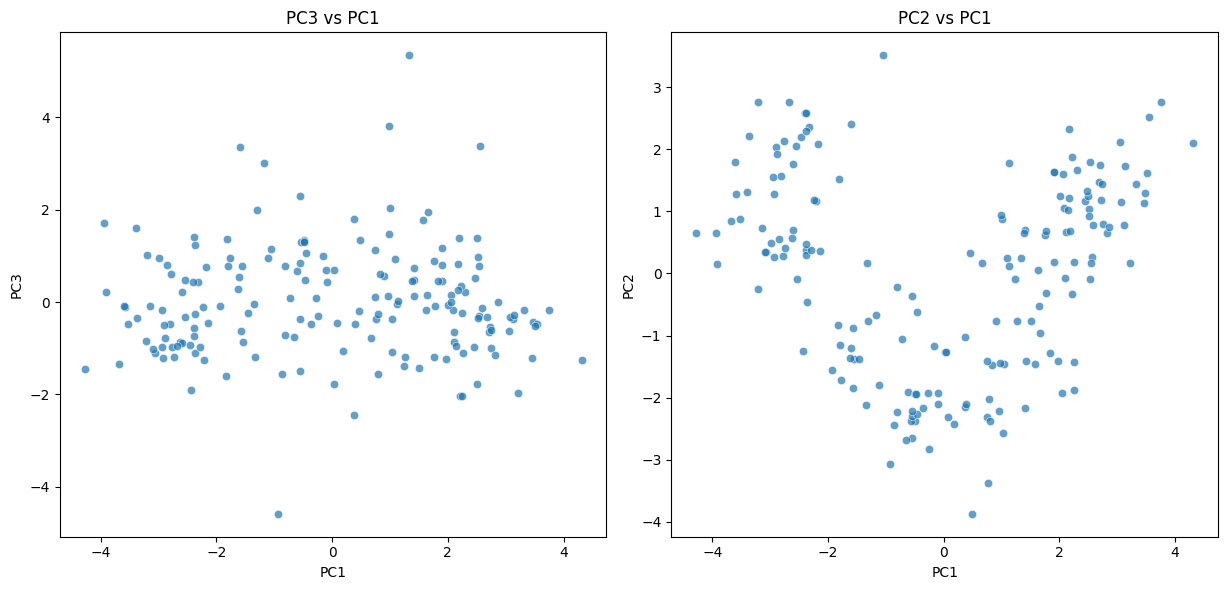

In [11]:
plt.figure(figsize=(18, 6))

# PC2 vs PC1
plt.subplot(1, 3, 3)
sns.scatterplot(data=df_pca, x='PC1', y='PC2', alpha=0.7)
plt.title('PC2 vs PC1')

# PC3 vs PC1
plt.subplot(1, 3, 2)
sns.scatterplot(data=df_pca, x='PC1', y='PC3', alpha=0.7)
plt.title('PC3 vs PC1')

plt.tight_layout()
plt.show()

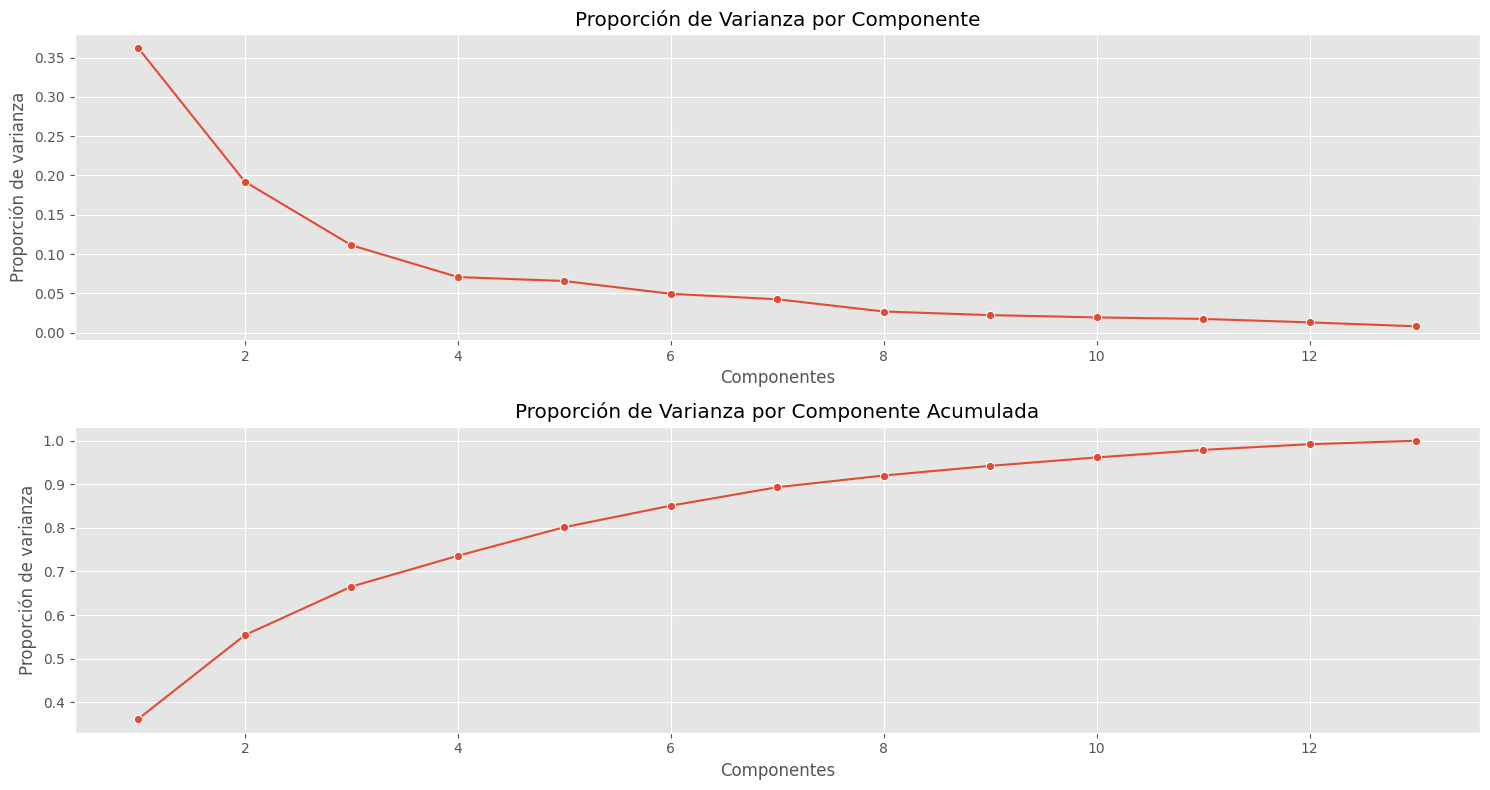

In [12]:
pca_var = pca.explained_variance_ratio_

plt.style.use('ggplot')
plt.figure(figsize=(15, 8))
plt.subplot(2,1,1)
sns.lineplot(x = range(1,len(pca_var)+1), y = pca_var, marker="o")
plt.xlabel('Componentes')
plt.ylabel('Proporción de varianza')
plt.title('Proporción de Varianza por Componente')

plt.subplot(2,1,2)
sns.lineplot(x = range(1,len(pca_var)+1), y = pca_var.cumsum(), marker="o")
plt.xlabel('Componentes')
plt.ylabel('Proporción de varianza')
plt.title('Proporción de Varianza por Componente Acumulada')

plt.tight_layout();

In [13]:
print(f'El 90% de la varianza está en las primeras {sum(pca_var.cumsum()<=0.93)} componentes')
print(f'En las primeras 7 componentes está el {round(pca_var.cumsum()[8-1]*100,2)}% de la varianza')

El 90% de la varianza está en las primeras 8 componentes
En las primeras 7 componentes está el 92.02% de la varianza


# Clusterización

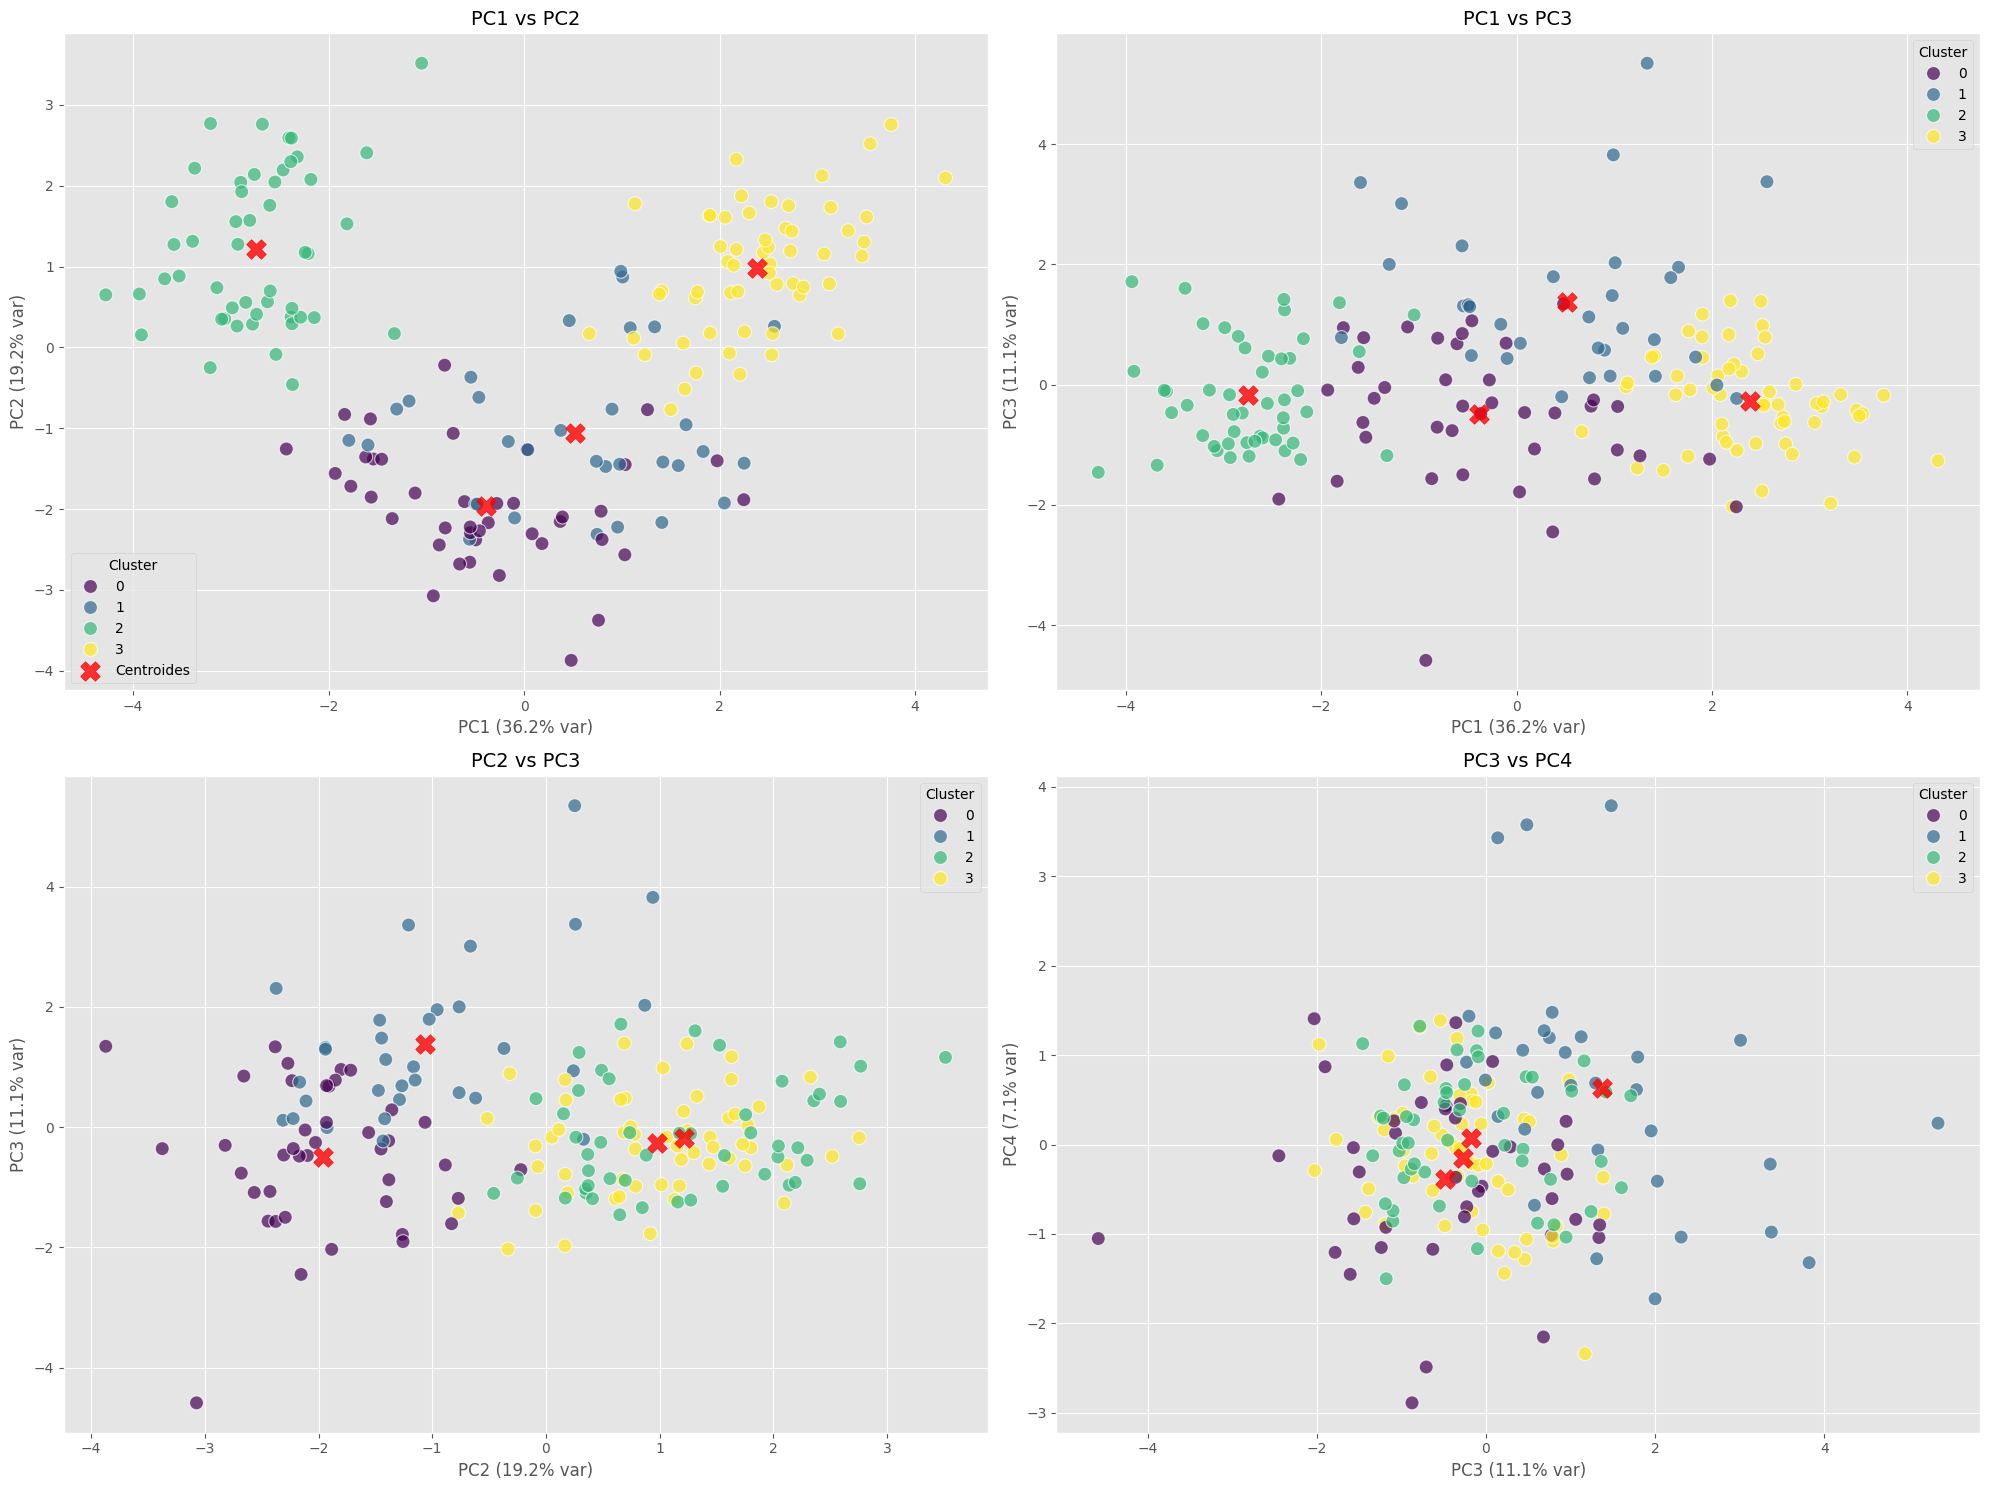

In [14]:
#METODO 1: K-MEANS

kmeans = KMeans(n_clusters=4, n_init=25, random_state=123)
kmeans.fit(x_scaled)
clusters_kmeans = kmeans.labels_

df_pca_clusters = pd.DataFrame({
    'PC1': x_pca[:, 0],
    'PC2': x_pca[:, 1],
    'PC3': x_pca[:, 2],
    'PC4': x_pca[:, 3],
    'Cluster': clusters_kmeans
})

centers_original = kmeans.cluster_centers_
centers_pca = pca.transform(centers_original)[:, :4]  # Solo primeros 4 componentes

plt.figure(figsize=(20, 15))

# PC1 vs PC2
plt.subplot(2, 2, 1)
sns.scatterplot(
    data=df_pca_clusters,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='red',
    s=200,
    alpha=0.8,
    marker='X',
    label='Centroides'
)
plt.title('PC1 vs PC2', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Cluster')
plt.grid(True)

# PC1 vs PC3
plt.subplot(2, 2, 2)
sns.scatterplot(
    data=df_pca_clusters,
    x='PC1',
    y='PC3',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 2],
    c='red',
    s=200,
    alpha=0.8,
    marker='X',
    label='Centroides'
)
plt.title('PC1 vs PC3', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)')
plt.grid(True)

# PC2 vs PC3
plt.subplot(2, 2, 3)
sns.scatterplot(
    data=df_pca_clusters,
    x='PC2',
    y='PC3',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.scatter(
    centers_pca[:, 1],
    centers_pca[:, 2],
    c='red',
    s=200,
    alpha=0.8,
    marker='X',
    label='Centroides'
)
plt.title('PC2 vs PC3', fontsize=14)
plt.xlabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.ylabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)')
plt.grid(True)

# PC3 vs PC4
plt.subplot(2, 2, 4)
sns.scatterplot(
    data=df_pca_clusters,
    x='PC3',
    y='PC4',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.scatter(
    centers_pca[:, 2],
    centers_pca[:, 3],
    c='red',
    s=200,
    alpha=0.8,
    marker='X',
    label='Centroides'
)
plt.title('PC3 vs PC4', fontsize=14)
plt.xlabel(f'PC3 ({pca.explained_variance_ratio_[2]*100:.1f}% var)')
plt.ylabel(f'PC4 ({pca.explained_variance_ratio_[3]*100:.1f}% var)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [15]:
# METODO 2: HIERARCHICAL CLUSTERING

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

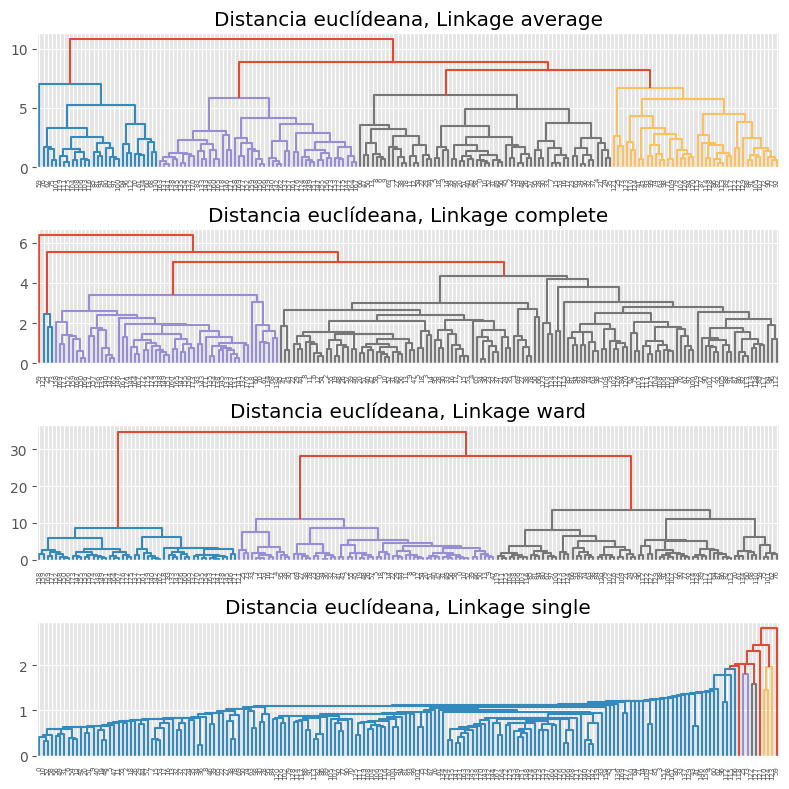

In [16]:
hcluster_data_x_complete = AgglomerativeClustering(metric = 'euclidean', linkage  = 'complete', distance_threshold = 0, n_clusters = None).fit(X = df_pca)
hcluster_data_x_average = AgglomerativeClustering(metric = 'euclidean', linkage  = 'average', distance_threshold = 0, n_clusters = None).fit(X = df_pca)
hcluster_data_x_ward = AgglomerativeClustering(metric = 'euclidean', linkage  = 'ward', distance_threshold = 0, n_clusters = None).fit(X = df_pca)
hcluster_data_x_single = AgglomerativeClustering(metric = 'euclidean', linkage  = 'single', distance_threshold = 0, n_clusters = None).fit(X = df_pca)


fig, axs = plt.subplots(4, 1, figsize=(8, 8))

plot_dendrogram(hcluster_data_x_complete, ax=axs[0])
axs[0].set_title("Distancia euclídeana, Linkage average")

plot_dendrogram(hcluster_data_x_average, ax=axs[1])
axs[1].set_title("Distancia euclídeana, Linkage complete")

plot_dendrogram(hcluster_data_x_ward, ax=axs[2])
axs[2].set_title("Distancia euclídeana, Linkage ward")

plot_dendrogram(hcluster_data_x_single, ax=axs[3])
axs[3].set_title("Distancia euclídeana, Linkage single")

plt.tight_layout();

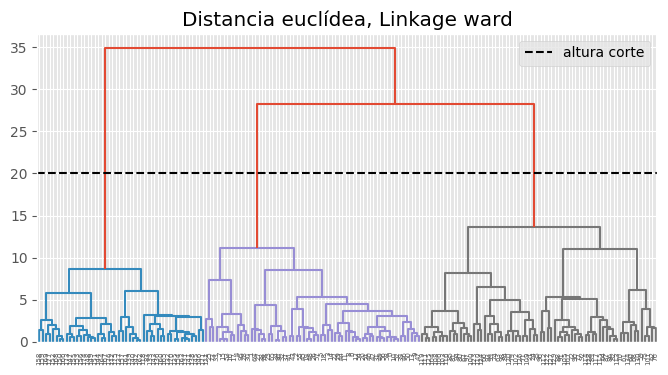

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
altura_corte = 20
plot_dendrogram(hcluster_data_x_ward, color_threshold=altura_corte, ax=ax)
ax.set_title("Distancia euclídea, Linkage ward")
ax.axhline(y=altura_corte, c = 'black', linestyle='--', label='altura corte')
ax.legend();

Determinar número óptimo de agrupaciones

In [18]:
df_pca.columns

Index(['PC1', 'PC2', 'PC3', 'PC4'], dtype='object')

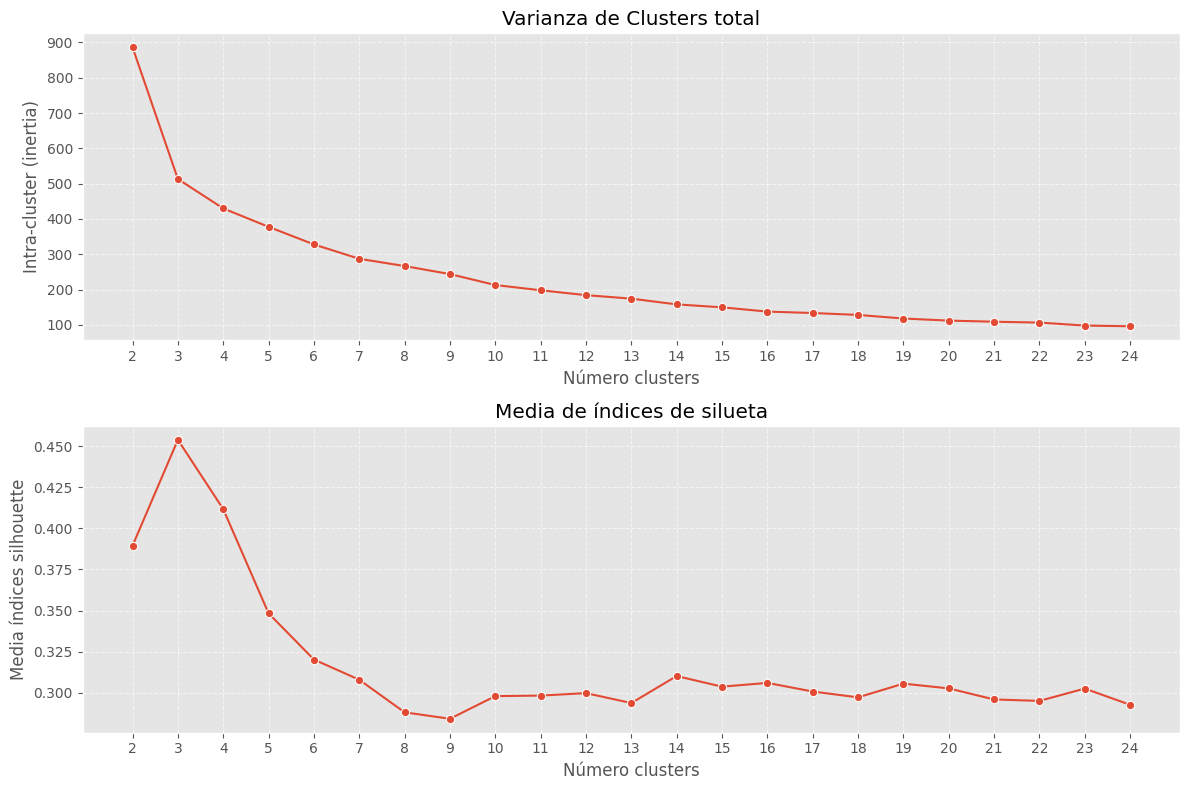

In [19]:
inertias = []
silhouette = []
range_k = range(2, 25)

plt.style.use('ggplot')

for k in range_k:
    Pcluster_data_x_pca = KMeans(n_clusters=k, n_init=5, random_state=123)

    # Elbow
    inertias.append(Pcluster_data_x_pca.fit(X=df_pca[['PC1', 'PC2', 'PC3']]).inertia_)

    # Silhouette
    silhouette.append(silhouette_score(df_pca[['PC1', 'PC2', 'PC3']],
    Pcluster_data_x_pca.fit_predict(df_pca[['PC1', 'PC2', 'PC3']])))

plt.figure(figsize=(12, 8))

# Gráfico de Inertia (Elbow)
plt.subplot(2, 1, 1)
ax1 = sns.lineplot(x=range_k, y=inertias, marker="o")
plt.xlabel('Número clusters')
plt.ylabel('Intra-cluster (inertia)')
plt.title('Varianza de Clusters total')
ax1.set_xticks(range_k)
ax1.grid(True, linestyle='--', alpha=0.6)

# Gráfico de Silhouette
plt.subplot(2, 1, 2)
ax2 = sns.lineplot(x=range_k, y=silhouette, marker="o")
plt.xlabel('Número clusters')
plt.ylabel('Media índices silhouette')
plt.title('Media de índices de silueta')
ax2.set_xticks(range_k)
ax2.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Se define que el numero optimo de clusters es 3.

Comparar y evaluar el desempeño:

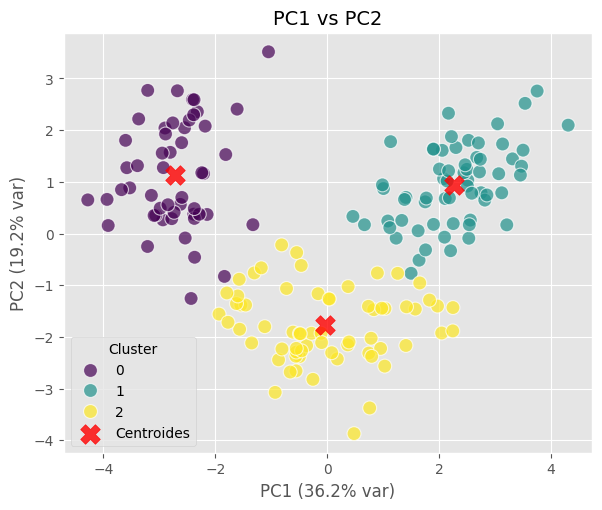

In [20]:
# Siendo 3 el numero de clusters, se define que el metodo jerarquico dio este mismo resultado, sin embargo, el metodo de k-means se hizo con 4 clusters. Ahora se representa con 3:

kmeans = KMeans(n_clusters=3, n_init=25, random_state=123)
kmeans.fit(x_scaled)
clusters_kmeans = kmeans.labels_

df_pca_clusters = pd.DataFrame({
    'PC1': x_pca[:, 0],
    'PC2': x_pca[:, 1],
    'PC3': x_pca[:, 2],
    'PC4': x_pca[:, 3],
    'Cluster': clusters_kmeans
})

centers_original = kmeans.cluster_centers_
centers_pca = pca.transform(centers_original)[:, :4]  # Solo primeros 4 componentes

plt.figure(figsize=(15, 12))

# PC1 vs PC2
plt.subplot(2, 2, 1)
sns.scatterplot(
    data=df_pca_clusters,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.scatter(
    centers_pca[:, 0],
    centers_pca[:, 1],
    c='red',
    s=200,
    alpha=0.8,
    marker='X',
    label='Centroides'
)
plt.title('PC1 vs PC2', fontsize=14)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.legend(title='Cluster')
plt.grid(True)

In [21]:
# Metrica de desempeño
score_original = silhouette_score(x_scaled, clusters_kmeans)
score_pca = silhouette_score(x_pca[:, :4], clusters_kmeans)
print("Score = ", score_pca)

Score =  0.4050568527010295


# Conclusiones

* Se crearon 4 PCAs a partir de los datos iniciales.
* Un silhouette score de 0.405 en el clustering con K-Means implica una estructura de grupos moderadamente definida. Esto indica clusters parcialmente separados, pero con solapamiento (esperado en datos de vinos, donde las características pueden variar gradualmente).
* Los gráficos PC1 vs PC2 y PC1 vs PC3 muestran cierta separación entre grupos, pero con solapamiento en algunas zonas, lo que sugiere que los clusters no son perfectamente distinguibles.
* El método del codo y el Silhouette Score sugieren que k=3 es un número óptimo de clusters.
* Visualmente, los clusters en PC1 vs PC2 se distribuyen alrededor de los centroides, pero algunos puntos están cerca de las fronteras.
* El dendrograma con linkage ward (el más utilizado) sugiere 3 clusters naturales, coincidiendo con K-Means.